In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set attractive whitegrid theme and color palette
sns.set_theme(style="whitegrid", palette="muted")


### ⭐ Data load :

In [28]:
df=pd.read_csv(r'C:\Users\ansh\OneDrive\Desktop\Ansh\rw\rw\DPFE\pr2\patient_health_records_1000_rows.csv')
df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P100001,69.0,Male,North,19.7,109.5,165.5,103.0,0
1,P100002,32.0,Female,South,19.5,119.9,186.0,78.3,0
2,P100003,78.0,Female,West,14.2,112.8,112.2,91.9,0
3,P100004,38.0,Male,East,20.5,97.4,219.9,114.9,0
4,P100005,41.0,Male,South,26.1,107.1,238.0,81.1,0


## ✨ Part A : Handling Missing Values

### 1️⃣ Identifying Missing Values and provide a summary report (percentage per column)

In [29]:
from IPython.core import async_helpers
print("Missing values in each column:")
print(df.isnull().sum())

print("\nPercentage of missing values in each column:")
print((df.isnull().sum() / len(df)) * 100)

Missing values in each column:
patient_id         0
age               30
gender            20
region            20
bmi               40
blood_pressure     0
cholesterol       30
glucose           30
disease_risk       0
dtype: int64

Percentage of missing values in each column:
patient_id        0.0
age               3.0
gender            2.0
region            2.0
bmi               4.0
blood_pressure    0.0
cholesterol       3.0
glucose           3.0
disease_risk      0.0
dtype: float64


### 2️⃣ Apply the following imputation techniques and compare results:

#### 💠Simple Imputer (Numerical): Replace missing BMI with mean

In [30]:
from sklearn.impute import SimpleImputer

df_mean=df.copy()
print(f'Before imputation null values in bmi column:- {df_mean["bmi"].isnull().sum()} ')

bmi_imputer = SimpleImputer(strategy='mean')
df_mean['bmi'] = bmi_imputer.fit_transform(df_mean[['bmi']])

print(f'After imputation null values in bmi column:- {df_mean["bmi"].isnull().sum()} ')

Before imputation null values in bmi column:- 40 
After imputation null values in bmi column:- 0 


#### 💠Simple Imputer (Categorical): Replace missing Region with most frequent value

In [31]:
print(f'Before imputation null values in region column:- {df["region"].isnull().sum()} ')

region_imputer = SimpleImputer(strategy='most_frequent')
df['region'] = region_imputer.fit_transform(df[['region']]).ravel()

print(f'After imputation null values in region column:- {df["region"].isnull().sum()} ')

Before imputation null values in region column:- 20 
After imputation null values in region column:- 0 


#### 💠Most Frequent Imputation: Replace missing Gender with the most common category.

In [32]:
print(f'Before imputation null values in gender column:- {df["gender"].isnull().sum()} ')

gender_imputer = SimpleImputer(strategy='most_frequent')
df['gender'] = gender_imputer.fit_transform(df[['gender']]).ravel()

print(f'After imputation null values in gender column:- {df["gender"].isnull().sum()} ')

Before imputation null values in gender column:- 20 
After imputation null values in gender column:- 0 


#### 💠Missing Indicator + Random sample Imputation : Create binary indicator columns for missingness and use random sampling to impute values.

In [33]:
df_bmi=df.copy()
print(f'Before imputation null values in bmi column:- {df_bmi["bmi"].isnull().sum()} ')
# indicator for missing bmi
df_bmi['bmi_missing'] = df_bmi['bmi'].isnull().astype(int)

# impute missing bmi values with random sampling
null_count_bmi = df_bmi['bmi'].isnull().sum()   

random_values_bmi = df_bmi['bmi'].dropna().sample(
    n=null_count_bmi,
    replace=True,
    random_state=42
).values

df_bmi.loc[df_bmi['bmi'].isnull(), 'bmi'] = random_values_bmi
print(f'After imputation null values in bmi column:- {df_bmi["bmi"].isnull().sum()} ')

df_bmi[['bmi', 'bmi_missing']]

Before imputation null values in bmi column:- 40 
After imputation null values in bmi column:- 0 


,bmi,bmi_missing
0,19.7,0
1,19.5,0
2,14.2,0
3,20.5,0
4,26.1,0
...,...,...
995,27.0,0
996,25.1,0
997,28.8,0
998,31.0,0


#### 💠KNN Imputer: Apply k-nearest Neighbors imputation for multivariate imputation. 

In [34]:
df_knn=df.copy()
from sklearn.impute import KNNImputer
num_cols = ["age", "bmi","cholesterol","glucose"]
print(f'Before imputation null values in numerical columns:- \n{df_knn[num_cols].isnull().sum()} ')

knn=KNNImputer(n_neighbors=5)
df_knn[num_cols] = knn.fit_transform(df_knn[num_cols])
print(f'After imputation null values in numerical columns:- \n{df_knn[num_cols].isnull().sum()} ')

Before imputation null values in numerical columns:- 
age            30
bmi            40
cholesterol    30
glucose        30
dtype: int64 
After imputation null values in numerical columns:- 
age            0
bmi            0
cholesterol    0
glucose        0
dtype: int64 


#### 💠MICE Algorithm: Perform chained equations imputation for multiple variables simultaneously.

In [35]:
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer

print(f'Before imputation null values in numerical columns:- \n{df[num_cols].isnull().sum()} ')

mice=IterativeImputer(max_iter=10, random_state=42)
df[num_cols] = mice.fit_transform(df[num_cols])
print(f'After imputation null values in numerical columns:- \n{df[num_cols].isnull().sum()} ')


Before imputation null values in numerical columns:- 
age            30
bmi            40
cholesterol    30
glucose        30
dtype: int64 
After imputation null values in numerical columns:- 
age            0
bmi            0
cholesterol    0
glucose        0
dtype: int64 


## ✨Part B: Handling Outliers

### 3️⃣. Detect and remove outliers using :

#### 💠 Z-score method: Identify patients with extreme cholesterol or glucose values.

In [36]:
from scipy import stats

z_scores = np.abs(stats.zscore(df['cholesterol']))
outliers = np.where(z_scores > 3)
print(f'Number of outliers in cholesterol column using Z-score method: {len(outliers[0])}')


Number of outliers in cholesterol column using Z-score method: 10


In [37]:
df_copy = df.copy()

Number of outliers in glucose column using Z-score method: 10


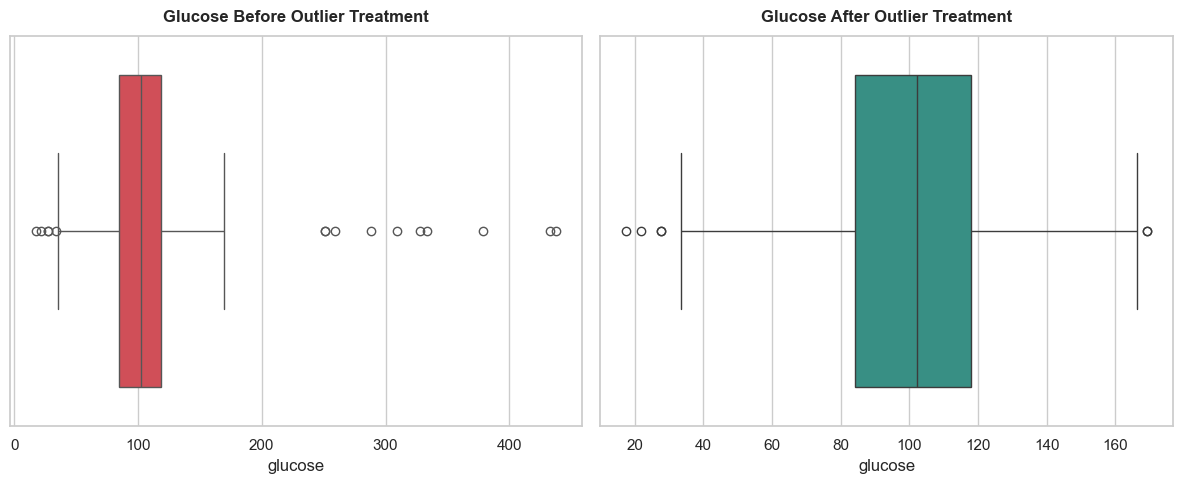

In [38]:
z_scores = np.abs(stats.zscore(df['glucose']))
outliers = np.where(z_scores > 3)
print(f'Number of outliers in glucose column using Z-score method: {len(outliers[0])}')
df = df[(z_scores < 3)]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df_copy['glucose'], color='#e63946')
plt.title('Glucose Before Outlier Treatment', fontsize=12, fontweight='bold', pad=10)

plt.subplot(1, 2, 2)
sns.boxplot(x=df['glucose'], color='#2a9d8f')
plt.title('Glucose After Outlier Treatment', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

#### 💠IQR method: Use interquartile range to detect unusual BMI values.

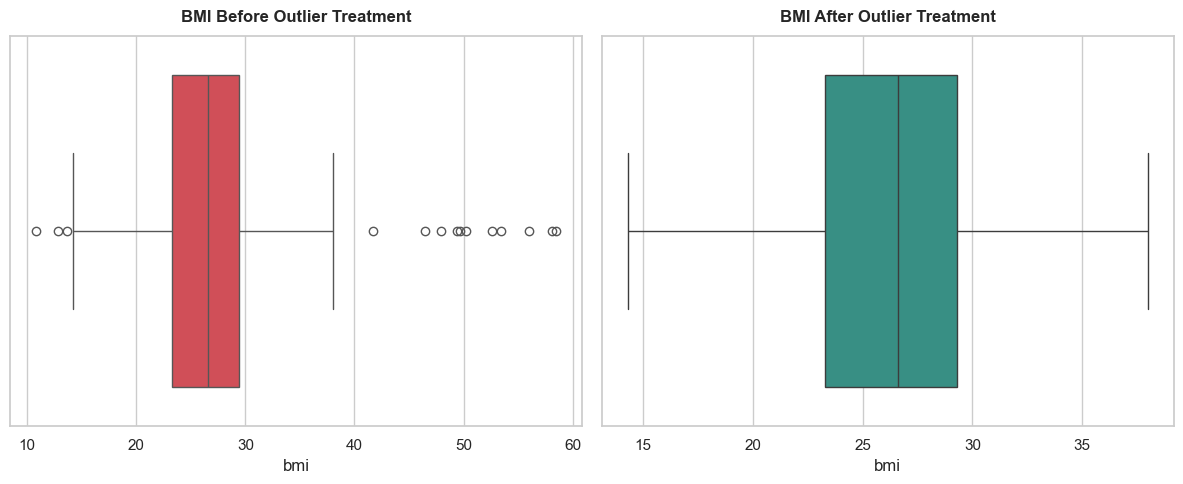

In [39]:
q1 = df['bmi'].quantile(0.25)
q3 = df['bmi'].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

df = df[(df['bmi'] >= low) & (df['bmi'] <= high)]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df_copy['bmi'], color='#e63946')
plt.title('BMI Before Outlier Treatment', fontsize=12, fontweight='bold', pad=10)

plt.subplot(1, 2, 2)
sns.boxplot(x=df['bmi'], color='#2a9d8f')
plt.title('BMI After Outlier Treatment', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

#### 💠Percentile method: Cap values below 1st percentile and above 99th percentile.

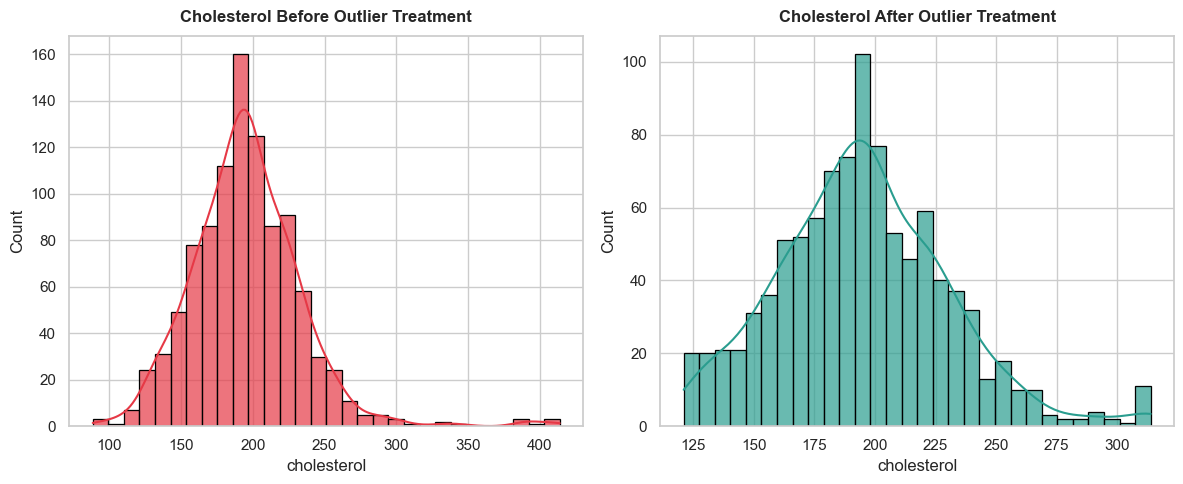

In [40]:
low = df['cholesterol'].quantile(0.01)
high = df['cholesterol'].quantile(0.99)

df['cholesterol'] = df['cholesterol'].clip(lower=low, upper=high)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_copy['cholesterol'], kde=True, bins=30, color='#e63946', edgecolor='black', alpha=0.7)
plt.title('Cholesterol Before Outlier Treatment', fontsize=12, fontweight='bold', pad=10)

plt.subplot(1, 2, 2)
sns.histplot(df['cholesterol'], kde=True, bins=30, color='#2a9d8f', edgecolor='black', alpha=0.7)
plt.title('Cholesterol After Outlier Treatment', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

### 4️⃣. Apply Winsorization to cap extreme values instead of removing them.

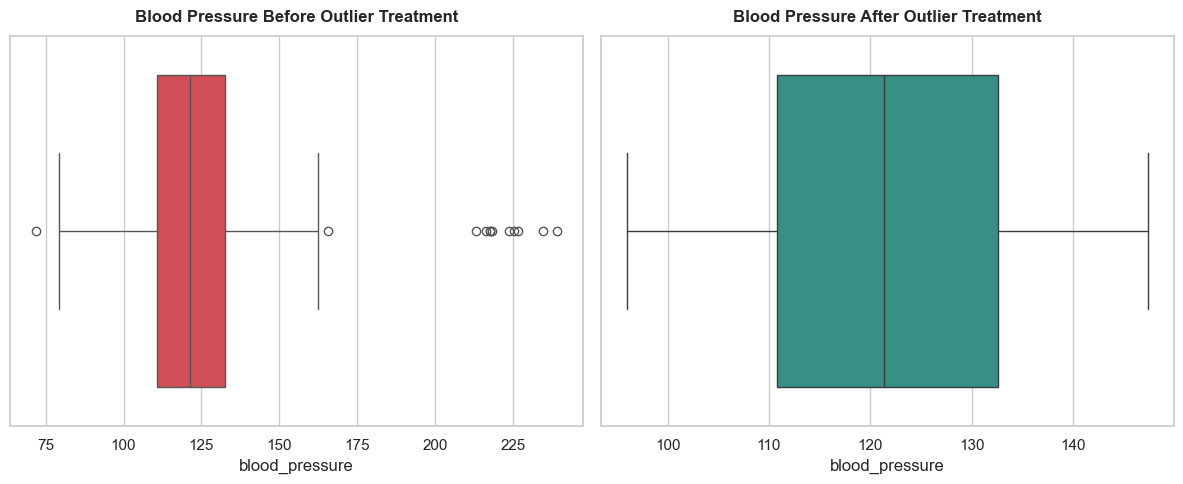

In [41]:
from scipy.stats.mstats import winsorize

df['blood_pressure'] = winsorize(df['blood_pressure'], limits=[0.05, 0.05])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df_copy['blood_pressure'], color='#e63946')
plt.title('Blood Pressure Before Outlier Treatment', fontsize=12, fontweight='bold', pad=10)

plt.subplot(1, 2, 2)
sns.boxplot(x=df['blood_pressure'], color='#2a9d8f')
plt.title('Blood Pressure After Outlier Treatment', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

### 5️⃣. Compare dataset and summary before vs after outlier treatment. 

In [42]:
shape_before = df_copy.shape
shape_after = df.shape

print(f'Shape of the dataset before outlier treatment: {shape_before}')
print(f'Shape of the dataset after outlier treatment: {shape_after}')

Shape of the dataset before outlier treatment: (1000, 9)
Shape of the dataset after outlier treatment: (975, 9)


In [43]:
print("\nSummary statistics before outlier treatment:")
print(df_copy.describe())
print("\nSummary statistics after outlier treatment:")
print(df.describe())


Summary statistics before outlier treatment:
               age          bmi  blood_pressure  cholesterol      glucose  \
count  1000.000000  1000.000000     1000.000000  1000.000000  1000.000000   
mean     51.154801    26.565276      122.320900   195.632749   103.501923   
std      19.736320     5.157742       17.952758    38.535469    34.254661   
min      18.000000    10.800000       71.900000    88.400000    17.600000   
25%      34.000000    23.300000      110.875000   172.150000    84.575000   
50%      51.142854    26.600000      121.350000   194.900000   102.650000   
75%      68.000000    29.400000      132.500000   217.150000   118.500000   
max      85.000000    58.500000      239.200000   413.900000   438.100000   

       disease_risk  
count   1000.000000  
mean       0.215000  
std        0.411028  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  

Summary statistics after outlier treatment:
              age

C:\Users\ansh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\ansh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\ansh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\ansh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarnin

## ✨Part C: Final Clean Dataset

In [45]:

print('Final dataset after treatment of missing values and outliers is ready for further analysis.')
df

Final dataset after treatment of missing values and outliers is ready for further analysis.


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P100001,69.0,Male,North,19.7,109.5,165.500000,103.0,0
1,P100002,32.0,Female,South,19.5,119.9,186.000000,78.3,0
3,P100004,38.0,Male,East,20.5,97.4,219.900000,114.9,0
4,P100005,41.0,Male,South,26.1,107.1,238.000000,81.1,0
5,P100006,20.0,Male,East,26.7,103.5,210.900000,91.5,0
...,...,...,...,...,...,...,...,...,...
995,P100996,61.0,Male,South,27.0,131.9,171.200000,91.8,0
996,P100997,41.0,Female,North,25.1,125.4,195.100000,67.2,0
997,P100998,47.0,Female,South,28.8,108.2,256.800000,106.4,0
998,P100999,76.0,Male,North,31.0,115.0,153.100000,99.1,1
